训练集: 4254 | 验证集: 1222 | 测试集: 603
类别权重: [0.95103955 1.1895974  0.9026098 ]

===== ResNet50 + SE + GAM 120 epochs =====
Epoch   1 | TrL 0.5884 | TrA 80.25% | ValL 0.4563 | ValA 87.73% | Best 87.73%
Epoch   2 | TrL 0.4564 | TrA 85.57% | ValL 0.4194 | ValA 88.38% | Best 88.38%
Epoch   3 | TrL 0.4203 | TrA 88.04% | ValL 0.3707 | ValA 89.77% | Best 89.77%
Epoch   4 | TrL 0.3938 | TrA 89.22% | ValL 0.3762 | ValA 89.85% | Best 89.85%
Epoch   5 | TrL 0.3806 | TrA 90.16% | ValL 0.3706 | ValA 89.77% | Best 89.85%
Epoch   6 | TrL 0.3467 | TrA 91.45% | ValL 0.3778 | ValA 89.77% | Best 89.85%
Epoch   7 | TrL 0.3383 | TrA 92.09% | ValL 0.3563 | ValA 90.59% | Best 90.59%
Epoch   8 | TrL 0.3375 | TrA 91.76% | ValL 0.3741 | ValA 91.16% | Best 91.16%
Epoch   9 | TrL 0.3383 | TrA 91.55% | ValL 0.3541 | ValA 90.92% | Best 91.16%
Epoch  10 | TrL 0.3068 | TrA 93.34% | ValL 0.3744 | ValA 90.92% | Best 91.16%
Epoch  11 | TrL 0.2985 | TrA 93.71% | ValL 0.3622 | ValA 91.00% | Best 91.16%
Epoch  12 | TrL 0.2937 |

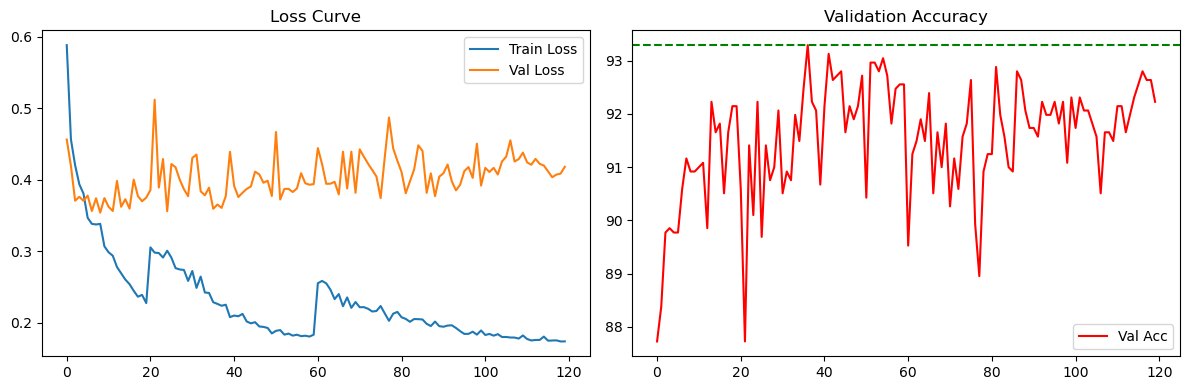

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import numpy as np
from PIL import Image
import os
import random
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# ===================== 配置 =====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_RESULT_DIR = r"D:\KY\SPHERE-LABELLED DATASET"
BASE_FOLDER_NAME = "Train_ResNet50_SE_GAM_FINAL"
BATCH_SIZE = 8
EPOCHS = 120
LR = 1e-4
WEIGHT_DECAY = 1e-5
DATA_ROOT = r"D:\KY\SPHERE-LABELLED DATASET\CNN_Data_Arranged\320p_split"
LABEL_MAP = {"clean": 0, "broken": 1, "dirty": 2}
SEED = 42

def get_next_result_dir(base_dir, base_name):
    idx = 1
    while True:
        new_dir = os.path.join(base_dir, f"{base_name}{idx}")
        if not os.path.exists(new_dir):
            os.makedirs(new_dir)
            return new_dir
        idx += 1
RESULT_SAVE_DIR = get_next_result_dir(BASE_RESULT_DIR, BASE_FOLDER_NAME)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# ===================== 数据加载 =====================
def load_data():
    train_imgs, train_labels = [], []
    val_imgs, val_labels = [], []
    test_imgs, test_labels = [], []

    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(DATA_ROOT, split)
        for cls_name, label in LABEL_MAP.items():
            cls_dir = os.path.join(split_dir, cls_name)
            imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                    if f.lower().endswith(('jpg', 'png', 'jpeg'))]
            if split == 'train':
                train_imgs += imgs
                train_labels += [label] * len(imgs)
            elif split == 'val':
                val_imgs += imgs
                val_labels += [label] * len(imgs)
            else:
                test_imgs += imgs
                test_labels += [label] * len(imgs)

    class_weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=train_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    print(f"训练集: {len(train_imgs)} | 验证集: {len(val_imgs)} | 测试集: {len(test_imgs)}")
    print(f"类别权重: {class_weights.cpu().numpy()}")
    return train_imgs, val_imgs, test_imgs, train_labels, val_labels, test_labels, class_weights

train_imgs, val_imgs, test_imgs, train_labels, val_labels, test_labels, CLASS_WEIGHTS = load_data()

# ===================== 数据集 =====================
class DefectDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)

# ===================== 数据增强 =====================
train_transform = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ===================== 加载器 =====================
train_dataset = DefectDataset(train_imgs, train_labels, train_transform)
val_dataset = DefectDataset(val_imgs, val_labels, val_test_transform)
test_dataset = DefectDataset(test_imgs, test_labels, val_test_transform)

sampler = WeightedRandomSampler(CLASS_WEIGHTS.cpu().numpy()[train_labels], len(train_labels), replacement=True)
train_loader = DataLoader(train_dataset, BATCH_SIZE, sampler=sampler, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=0)

# ===================== SE模块 =====================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels//reduction),
            nn.ReLU(True),
            nn.Linear(channels//reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b,c,_,_ = x.size()
        y = self.avg(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x * y.expand_as(x)

# ===================== GAM 模块 =====================
class GAM_ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels)
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = x.mean(dim=[2,3]) + x.amax(dim=[2,3])
        y = self.fc(y).view(b,c,1,1)
        return x * y

class GAM_SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        max_out,_ = torch.max(x, dim=1, keepdim=True)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        out = torch.cat([max_out, avg_out], dim=1)
        out = self.conv(out)
        return x * self.sigmoid(out)

class GAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.ca = GAM_ChannelAttention(channels, reduction)
        self.sa = GAM_SpatialAttention()
    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

# ===================== 模型 =====================
class ResNet50_SE_GAM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # 这里修复了：resnet50 全小写
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.se = SEBlock(2048)
        self.gam = GAM(2048)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.se(x)
        x = self.gam(x)
        x = self.avg(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

model = ResNet50_SE_GAM().to(DEVICE)

# ===================== 损失 & 优化器 =====================
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)

# ===================== 训练 =====================
best_val = 0.0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("\n===== ResNet50 + SE + GAM 120 epochs =====")

for epoch in range(EPOCHS):
    # 训练
    model.train()
    tr_loss = 0.0
    tr_correct = 0
    tr_total = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        tr_correct += (pred == y).sum().item()
        tr_total += x.size(0)

    tr_loss /= tr_total
    tr_acc = 100 * tr_correct / tr_total

    # 验证
    model.eval()
    v_loss = 0.0
    v_correct = 0
    v_total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            v_loss += criterion(out, y).item() * x.size(0)
            pred = out.argmax(1)
            v_correct += (pred == y).sum().item()
            v_total += x.size(0)

    v_loss /= v_total
    v_acc = 100 * v_correct / v_total

    # 更新最佳模型
    if v_acc > best_val:
        best_val = v_acc
        torch.save(model.state_dict(), os.path.join(RESULT_SAVE_DIR, "best.pth"))

    # 保存数据
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(v_loss)
    val_accs.append(v_acc)

    # ===================== 你要的 5 指标输出 =====================
    print(f"Epoch {epoch+1:3d} | TrL {tr_loss:.4f} | TrA {tr_acc:.2f}% | ValL {v_loss:.4f} | ValA {v_acc:.2f}% | Best {best_val:.2f}%")

    scheduler.step()

# 保存 npy 文件
np.save(os.path.join(RESULT_SAVE_DIR, "train_losses.npy"), np.array(train_losses))
np.save(os.path.join(RESULT_SAVE_DIR, "train_accs.npy"), np.array(train_accs))
np.save(os.path.join(RESULT_SAVE_DIR, "val_losses.npy"), np.array(val_losses))
np.save(os.path.join(RESULT_SAVE_DIR, "val_accs.npy"), np.array(val_accs))

# 绘图
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(122)
plt.plot(val_accs, label='Val Acc', c='r')
plt.axhline(y=best_val, color='g', linestyle='--')
plt.title('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_SAVE_DIR, "curve.png"), dpi=300)

# 测试
model.load_state_dict(torch.load(os.path.join(RESULT_SAVE_DIR, "best.pth")))
model.eval()
cor = tot = 0
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        cor += (model(x).argmax(1) == y).sum().item()
        tot += x.size(0)
test_acc = 100 * cor / tot

print("\n============ 最终结果 ============")
print(f"最佳验证准确率: {best_val:.2f}%")
print(f"测试集准确率:    {test_acc:.2f}%")

with open(os.path.join(RESULT_SAVE_DIR, "result.txt"),"w") as f:
    f.write(f"Best Val Acc: {best_val:.2f}%\n")
    f.write(f"Test Acc: {test_acc:.2f}%\n")